In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

product_sales = pd.read_csv(
    "/content/sales_integrated.csv"
)

print("Dataset shape:", product_sales.shape)
display(product_sales.head())

Dataset shape: (130402, 55)


,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total,customer_id,...,pincode,region,branch_id_customer,credit_limit,current_balance,payment_terms_customer,customer_since,last_purchase_date_customer,total_purchase_value,customer_rating
0,SO-990591,1,P018,19,11300,28,214700,60116.0,274816.0,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
1,SO-990591,2,P026,2,310,18,620,111.6,731.6,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
2,SO-990591,3,P026,3,310,18,930,167.4,1097.4,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
3,SO-990591,4,P013,9,1450,18,13050,2349.0,15399.0,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
4,SO-990591,5,P004,3,39800,28,119400,33432.0,152832.0,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3


Check Columns

In [4]:
print(product_sales.columns.tolist())

inventory_columns = [
    col for col in product_sales.columns
    if any(word in col.lower()
           for word in ["inventory", "stock", "reorder", "safety", "max_stock"])
]

print("Inventory-related columns:")
print(inventory_columns)

required_inventory_columns = [
    "product_id",
    "product_name",
    "unit_cost",
    "reorder_level",
    "safety_stock",
    "max_stock_level",
    "lead_time_days",
    "last_purchase_price",
    "last_purchase_date"
]

missing_columns = [
    col for col in required_inventory_columns
    if col not in product_sales.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required inventory-related columns are available.")

['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'product_name', 'category', 'machine_type', 'brand', 'model_compatibility', 'unit_cost', 'unit_price_product', 'margin_percentage', 'gst_rate_product', 'weight_kg', 'dimensions_cm', 'material_type', 'warranty_months', 'reorder_level', 'safety_stock', 'max_stock_level', 'lead_time_days', 'criticality_level', 'usage_frequency', 'uom', 'last_purchase_price', 'last_purchase_date', 'customer_type', 'industry_segment', 'city', 'state', 'pincode', 'region', 'branch_id_customer', 'credit_limit', 'current_balance', 'payment_terms_customer', 'customer_since', 'last_purchase_date_customer', 'total_purchase_value', 'customer_rating']
Inventory-related columns:
['reorder_level', 'safety_stock', 'max_stock_level']


Convert Inventory Fields to Numeric

In [5]:
numeric_inventory_columns = [
    "unit_cost",
    "reorder_level",
    "safety_stock",
    "max_stock_level",
    "lead_time_days",
    "last_purchase_price"
]

for col in numeric_inventory_columns:
    product_sales[col] = pd.to_numeric(
        product_sales[col],
        errors="coerce"
    )

Convert Purchase Date

In [6]:
product_sales["last_purchase_date"] = pd.to_datetime(
    product_sales["last_purchase_date"],
    errors="coerce"
)

print(product_sales["last_purchase_date"].dtype)

datetime64[ns]


Check Missing Values

In [7]:
inventory_missing = (
    product_sales[
        numeric_inventory_columns
    ]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(inventory_missing)

,0
unit_cost,0
reorder_level,0
safety_stock,0
max_stock_level,0
lead_time_days,0
last_purchase_price,0


In [8]:
print(
    "Missing last purchase dates:",
    product_sales["last_purchase_date"].isna().sum()
)

Missing last purchase dates: 0


Check Unusal Values

In [9]:
print("Negative unit cost:",
      (product_sales["unit_cost"] < 0).sum())

print("Negative reorder level:",
      (product_sales["reorder_level"] < 0).sum())

print("Negative safety stock:",
      (product_sales["safety_stock"] < 0).sum())

print("Negative maximum stock:",
      (product_sales["max_stock_level"] < 0).sum())

print("Negative lead time:",
      (product_sales["lead_time_days"] < 0).sum())

print("Negative last purchase price:",
      (product_sales["last_purchase_price"] < 0).sum())

Negative unit cost: 0
Negative reorder level: 0
Negative safety stock: 0
Negative maximum stock: 0
Negative lead time: 0
Negative last purchase price: 0


Check Stock Level Logic

In [10]:
invalid_stock_levels = product_sales[
    (product_sales["safety_stock"] >
     product_sales["reorder_level"])
    |
    (product_sales["reorder_level"] >
     product_sales["max_stock_level"])
]

print(
    "Records with inconsistent stock thresholds:",
    len(invalid_stock_levels)
)

display(
    invalid_stock_levels[
        [
            "product_id",
            "product_name",
            "safety_stock",
            "reorder_level",
            "max_stock_level"
        ]
    ].head(20)
)

Records with inconsistent stock thresholds: 0


,product_id,product_name,safety_stock,reorder_level,max_stock_level


Create Product-Level Inventory Requirements

In [11]:
product_inventory = (
    product_sales
    .groupby(
        [
            "product_id",
            "product_name"
        ],
        as_index=False
    )
    .agg(
        unit_cost=("unit_cost", "mean"),
        reorder_level=("reorder_level", "mean"),
        safety_stock=("safety_stock", "mean"),
        max_stock_level=("max_stock_level", "mean"),
        lead_time_days=("lead_time_days", "mean"),
        last_purchase_price=("last_purchase_price", "mean"),
        last_purchase_date=("last_purchase_date", "max")
    )
)

display(product_inventory.head())

,product_id,product_name,unit_cost,reorder_level,safety_stock,max_stock_level,lead_time_days,last_purchase_price,last_purchase_date
0,P001,Hydraulic Pump HP-300,18950.0,15.0,10.0,40.0,21.0,18500.0,2019-03-15
1,P002,Engine Oil Filter OF-90,450.0,80.0,40.0,200.0,7.0,430.0,2019-07-22
2,P003,Air Filter AF-120,820.0,60.0,30.0,150.0,7.0,800.0,2020-01-10
3,P004,Track Chain TC-45,32500.0,8.0,4.0,20.0,30.0,32000.0,2020-06-18
4,P005,Fuel Injector FI-220,6350.0,30.0,15.0,80.0,18.0,6200.0,2020-11-05


Check Product Count

In [12]:
print(
    "Products analysed:",
    product_inventory["product_id"].nunique()
)

Products analysed: 30


Calculate Required Stock Range

In [14]:
product_inventory["stock_capacity_range"] = (
    product_inventory["max_stock_level"]
    - product_inventory["safety_stock"]
)

display(
    product_inventory[
        [
            "product_id",
            "product_name",
            "safety_stock",
            "reorder_level",
            "max_stock_level",
            "stock_capacity_range"
        ]
    ].head(20)
)

,product_id,product_name,safety_stock,reorder_level,max_stock_level,stock_capacity_range
0,P001,Hydraulic Pump HP-300,10.0,15.0,40.0,30.0
1,P002,Engine Oil Filter OF-90,40.0,80.0,200.0,160.0
2,P003,Air Filter AF-120,30.0,60.0,150.0,120.0
3,P004,Track Chain TC-45,4.0,8.0,20.0,16.0
4,P005,Fuel Injector FI-220,15.0,30.0,80.0,65.0
5,P006,Alternator ALT-500,6.0,12.0,30.0,24.0
6,P007,Hydraulic Hose HH-60,35.0,70.0,200.0,165.0
7,P008,Bucket Tooth BT-10,60.0,120.0,300.0,240.0
8,P009,Starter Motor SM-700,5.0,10.0,25.0,20.0
9,P010,Turbocharger TB-900,3.0,6.0,15.0,12.0


Calculate Reorder Buffer

In [15]:
product_inventory["reorder_buffer"] = (
    product_inventory["reorder_level"]
    - product_inventory["safety_stock"]
)

Analyse Lead Time

In [16]:
lead_time_summary = product_inventory[
    "lead_time_days"
].describe()

display(lead_time_summary)

,lead_time_days
count,30.000000
mean,17.000000
std,9.281052
min,4.000000
25%,9.000000
50%,18.000000
75%,22.000000
max,40.000000


Find products with the longest lead times:

In [17]:
longest_lead_time = (
    product_inventory
    .sort_values(
        "lead_time_days",
        ascending=False
    )
    .head(10)
)

display(
    longest_lead_time[
        [
            "product_id",
            "product_name",
            "lead_time_days",
            "reorder_level",
            "safety_stock"
        ]
    ]
)

,product_id,product_name,lead_time_days,reorder_level,safety_stock
14,P015,Engine Block EB-600,40.0,3.0,2.0
13,P014,Transmission Assembly TA-800,35.0,4.0,2.0
3,P004,Track Chain TC-45,30.0,8.0,4.0
9,P010,Turbocharger TB-900,28.0,6.0,3.0
20,P021,Boom Cylinder BC-400,26.0,5.0,3.0
10,P011,Hydraulic Cylinder HC-200,24.0,10.0,5.0
18,P019,Swing Motor SWM-350,24.0,6.0,3.0
23,P024,Track Roller TR-60,22.0,8.0,4.0
8,P009,Starter Motor SM-700,22.0,10.0,5.0
0,P001,Hydraulic Pump HP-300,21.0,15.0,10.0


Inventory Value at Maximum Stock Level

In [18]:
product_inventory["max_stock_value"] = (
    product_inventory["max_stock_level"]
    * product_inventory["unit_cost"]
)

Safety Stock Value

In [19]:
product_inventory["safety_stock_value"] = (
    product_inventory["safety_stock"]
    * product_inventory["unit_cost"]
)

Reorder Level Value

In [20]:
product_inventory["reorder_stock_value"] = (
    product_inventory["reorder_level"]
    * product_inventory["unit_cost"]
)

Display Stock Value Analysis

In [21]:
display(
    product_inventory[
        [
            "product_id",
            "product_name",
            "unit_cost",
            "safety_stock_value",
            "reorder_stock_value",
            "max_stock_value"
        ]
    ].head(20)
)

,product_id,product_name,unit_cost,safety_stock_value,reorder_stock_value,max_stock_value
0,P001,Hydraulic Pump HP-300,18950.0,189500.0,284250.0,758000.0
1,P002,Engine Oil Filter OF-90,450.0,18000.0,36000.0,90000.0
2,P003,Air Filter AF-120,820.0,24600.0,49200.0,123000.0
3,P004,Track Chain TC-45,32500.0,130000.0,260000.0,650000.0
4,P005,Fuel Injector FI-220,6350.0,95250.0,190500.0,508000.0
5,P006,Alternator ALT-500,8650.0,51900.0,103800.0,259500.0
6,P007,Hydraulic Hose HH-60,980.0,34300.0,68600.0,196000.0
7,P008,Bucket Tooth BT-10,340.0,20400.0,40800.0,102000.0
8,P009,Starter Motor SM-700,11450.0,57250.0,114500.0,286250.0
9,P010,Turbocharger TB-900,28900.0,86700.0,173400.0,433500.0


Inventory Turnover

In [23]:
# Create product-level sales summary

product_sales_summary = (
    product_sales
    .groupby("product_id")
    .agg(
        total_units_sold=("quantity", "sum"),
        total_revenue=("line_total", "sum")
    )
    .reset_index()
)

display(product_sales_summary.head())

,product_id,total_units_sold,total_revenue
0,P001,45389,1112030500
1,P002,45342,32646240
2,P003,45684,57105000
3,P004,45575,1813885000
4,P005,45026,380469700


Merge it with inventory requirements:

In [24]:
inventory_analysis = product_inventory.merge(
    product_sales_summary,
    on="product_id",
    how="left"
)

inventory_analysis[
    ["total_units_sold", "total_revenue"]
] = inventory_analysis[
    ["total_units_sold", "total_revenue"]
].fillna(0)

display(inventory_analysis.head())

,product_id,product_name,unit_cost,reorder_level,safety_stock,max_stock_level,lead_time_days,last_purchase_price,last_purchase_date,stock_capacity_range,reorder_buffer,max_stock_value,safety_stock_value,reorder_stock_value,total_units_sold,total_revenue
0,P001,Hydraulic Pump HP-300,18950.0,15.0,10.0,40.0,21.0,18500.0,2019-03-15,30.0,5.0,758000.0,189500.0,284250.0,45389,1112030500
1,P002,Engine Oil Filter OF-90,450.0,80.0,40.0,200.0,7.0,430.0,2019-07-22,160.0,40.0,90000.0,18000.0,36000.0,45342,32646240
2,P003,Air Filter AF-120,820.0,60.0,30.0,150.0,7.0,800.0,2020-01-10,120.0,30.0,123000.0,24600.0,49200.0,45684,57105000
3,P004,Track Chain TC-45,32500.0,8.0,4.0,20.0,30.0,32000.0,2020-06-18,16.0,4.0,650000.0,130000.0,260000.0,45575,1813885000
4,P005,Fuel Injector FI-220,6350.0,30.0,15.0,80.0,18.0,6200.0,2020-11-05,65.0,15.0,508000.0,95250.0,190500.0,45026,380469700


ABC/Pareto Analysis<br>
Perform ABC analysis using maximum stock value.

In [25]:
abc_analysis = (
    inventory_analysis
    .sort_values(
        "max_stock_value",
        ascending=False
    )
    .reset_index(drop=True)
)

Calculate Cumulative Value

In [26]:
abc_analysis["cumulative_stock_value"] = (
    abc_analysis["max_stock_value"].cumsum()
)

abc_analysis["cumulative_percentage"] = (
    abc_analysis["cumulative_stock_value"]
    / abc_analysis["max_stock_value"].sum()
) * 100

Assign ABC Classes

In [27]:
abc_analysis["ABC_class"] = np.select(
    [
        abc_analysis["cumulative_percentage"] <= 80,
        abc_analysis["cumulative_percentage"] <= 95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

In [28]:
display(
    abc_analysis[
        [
            "product_id",
            "product_name",
            "max_stock_value",
            "cumulative_percentage",
            "ABC_class"
        ]
    ].head(20)
)

,product_id,product_name,max_stock_value,cumulative_percentage,ABC_class
0,P014,Transmission Assembly TA-800,822000.0,8.289926,A
1,P015,Engine Block EB-600,764000.0,15.994917,A
2,P001,Hydraulic Pump HP-300,758000.0,23.639398,A
3,P021,Boom Cylinder BC-400,712000.0,30.819966,A
4,P004,Track Chain TC-45,650000.0,37.375260,A
5,P011,Hydraulic Cylinder HC-200,537500.0,42.795984,A
6,P005,Fuel Injector FI-220,508000.0,47.919198,A
7,P019,Swing Motor SWM-350,468000.0,52.639010,A
8,P016,Radiator RD-250,468000.0,57.358822,A
9,P010,Turbocharger TB-900,433500.0,61.730698,A


ABC Summary

In [29]:
abc_summary = (
    abc_analysis
    .groupby("ABC_class")
    .agg(
        number_of_products=("product_id", "nunique"),
        maximum_stock_value=("max_stock_value", "sum")
    )
    .reset_index()
)

abc_summary["value_percentage"] = (
    abc_summary["maximum_stock_value"]
    / abc_summary["maximum_stock_value"].sum()
) * 100

abc_summary["value_percentage"] = (
    abc_summary["value_percentage"].round(2)
)

display(abc_summary)

,ABC_class,number_of_products,maximum_stock_value,value_percentage
0,A,16,7930750.0,79.98
1,B,8,1427900.0,14.40
2,C,6,557000.0,5.62


ABC visualization

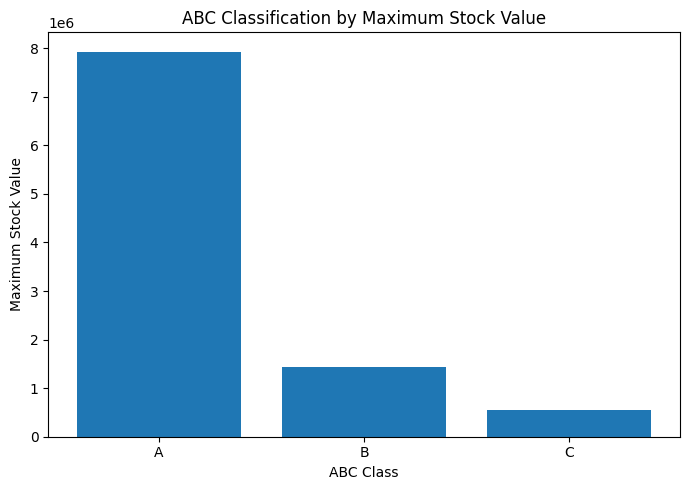

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    abc_summary["ABC_class"],
    abc_summary["maximum_stock_value"]
)

plt.xlabel("ABC Class")
plt.ylabel("Maximum Stock Value")
plt.title("ABC Classification by Maximum Stock Value")

plt.tight_layout()
plt.show()

Sales + Inventory Requirements Analysis

In [35]:
# Product Movement Classification

# Create product-level sales quantity
product_movement = (
    product_sales
    .groupby("product_id")
    .agg(
        total_units_sold=("quantity", "sum")
    )
    .reset_index()
)

# Calculate movement thresholds
quantity_25th = product_movement["total_units_sold"].quantile(0.25)
quantity_75th = product_movement["total_units_sold"].quantile(0.75)

print("25th percentile:", quantity_25th)
print("75th percentile:", quantity_75th)

# Classify products
product_movement["movement_category"] = np.select(
    [
        product_movement["total_units_sold"] >= quantity_75th,
        product_movement["total_units_sold"] <= quantity_25th
    ],
    [
        "Fast-Moving",
        "Slow-Moving"
    ],
    default="Medium-Moving"
)

# Check classification
display(product_movement.head(20))

25th percentile: 45081.75
75th percentile: 46116.0


,product_id,total_units_sold,movement_category
0,P001,45389,Medium-Moving
1,P002,45342,Medium-Moving
2,P003,45684,Medium-Moving
3,P004,45575,Medium-Moving
4,P005,45026,Slow-Moving
5,P006,46731,Fast-Moving
6,P007,46468,Fast-Moving
7,P008,45376,Medium-Moving
8,P009,44946,Slow-Moving
9,P010,46964,Fast-Moving


In [37]:
# Remove existing movement columns if they already exist
columns_to_remove = [
    "movement_category",
    "total_units_sold"
]

inventory_analysis = inventory_analysis.drop(
    columns=[
        col for col in columns_to_remove
        if col in inventory_analysis.columns
    ]
)

# Merge product movement information
inventory_analysis = inventory_analysis.merge(
    product_movement[
        [
            "product_id",
            "total_units_sold",
            "movement_category"
        ]
    ],
    on="product_id",
    how="left"
)

display(
    inventory_analysis[
        [
            "product_id",
            "product_name",
            "total_units_sold",
            "movement_category"
        ]
    ].head(20)
)

,product_id,product_name,total_units_sold,movement_category
0,P001,Hydraulic Pump HP-300,45389,Medium-Moving
1,P002,Engine Oil Filter OF-90,45342,Medium-Moving
2,P003,Air Filter AF-120,45684,Medium-Moving
3,P004,Track Chain TC-45,45575,Medium-Moving
4,P005,Fuel Injector FI-220,45026,Slow-Moving
5,P006,Alternator ALT-500,46731,Fast-Moving
6,P007,Hydraulic Hose HH-60,46468,Fast-Moving
7,P008,Bucket Tooth BT-10,45376,Medium-Moving
8,P009,Starter Motor SM-700,44946,Slow-Moving
9,P010,Turbocharger TB-900,46964,Fast-Moving


Fast-Moving Products with Stock Requirements

In [38]:
fast_moving_products = (
    inventory_analysis[
        inventory_analysis["movement_category"]
        == "Fast-Moving"
    ]
    .sort_values(
        "max_stock_value",
        ascending=False
    )
)

display(
    fast_moving_products[
        [
            "product_id",
            "product_name",
            "total_units_sold",
            "safety_stock",
            "reorder_level",
            "max_stock_level",
            "max_stock_value"
        ]
    ].head(20)
)

,product_id,product_name,total_units_sold,safety_stock,reorder_level,max_stock_level,max_stock_value
20,P021,Boom Cylinder BC-400,46364,3.0,5.0,20.0,712000.0
10,P011,Hydraulic Cylinder HC-200,46612,5.0,10.0,25.0,537500.0
15,P016,Radiator RD-250,46306,10.0,20.0,60.0,468000.0
9,P010,Turbocharger TB-900,46964,3.0,6.0,15.0,433500.0
5,P006,Alternator ALT-500,46731,6.0,12.0,30.0,259500.0
6,P007,Hydraulic Hose HH-60,46468,35.0,70.0,200.0,196000.0
28,P029,Pressure Sensor PS-90,47066,12.0,25.0,60.0,165000.0
27,P028,Light Assembly LA-18,46164,20.0,40.0,100.0,145000.0


Slow-Moving Products with High Stock Requirements

In [39]:
slow_moving_products = (
    inventory_analysis[
        inventory_analysis["movement_category"]
        == "Slow-Moving"
    ]
    .sort_values(
        "max_stock_value",
        ascending=False
    )
)

display(
    slow_moving_products[
        [
            "product_id",
            "product_name",
            "total_units_sold",
            "safety_stock",
            "reorder_level",
            "max_stock_level",
            "max_stock_value"
        ]
    ].head(20)
)

,product_id,product_name,total_units_sold,safety_stock,reorder_level,max_stock_level,max_stock_value
13,P014,Transmission Assembly TA-800,45035,2.0,4.0,12.0,822000.0
4,P005,Fuel Injector FI-220,45026,15.0,30.0,80.0,508000.0
8,P009,Starter Motor SM-700,44946,5.0,10.0,25.0,286250.0
17,P018,Wheel Rim WR-24,45027,6.0,12.0,30.0,246000.0
12,P013,Seal Kit SK-15,44081,40.0,80.0,200.0,190000.0
22,P023,Idler Wheel IW-55,44437,3.0,6.0,18.0,165600.0
23,P024,Track Roller TR-60,44022,4.0,8.0,22.0,162800.0
25,P026,Grease Cartridge GC-5,44844,100.0,200.0,500.0,90000.0


Lead Time vs Safety Stock<br>
This helps investigate whether products with longer lead times have higher safety-stock requirements.

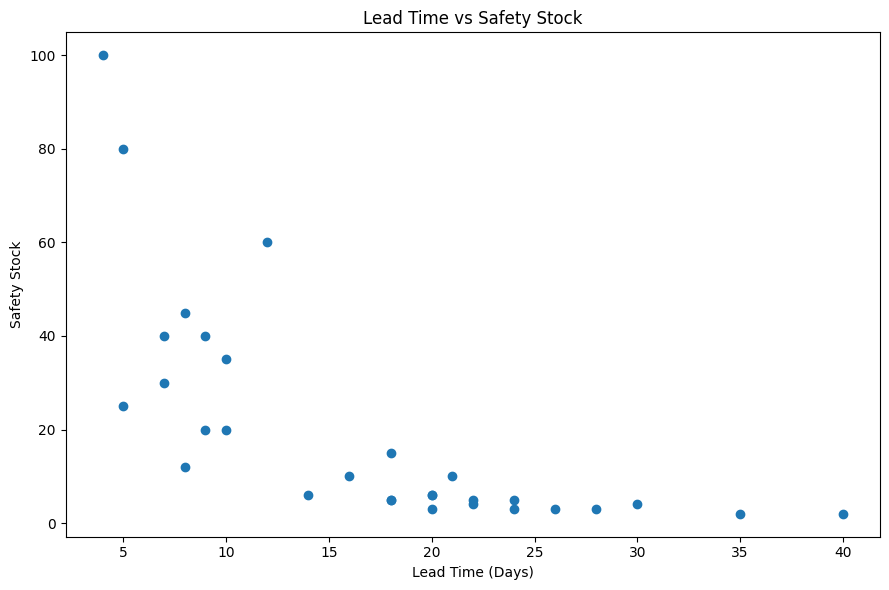

In [40]:
plt.figure(figsize=(9, 6))

plt.scatter(
    product_inventory["lead_time_days"],
    product_inventory["safety_stock"]
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Safety Stock")
plt.title("Lead Time vs Safety Stock")

plt.tight_layout()
plt.show()

Maximum Stock Value by Product

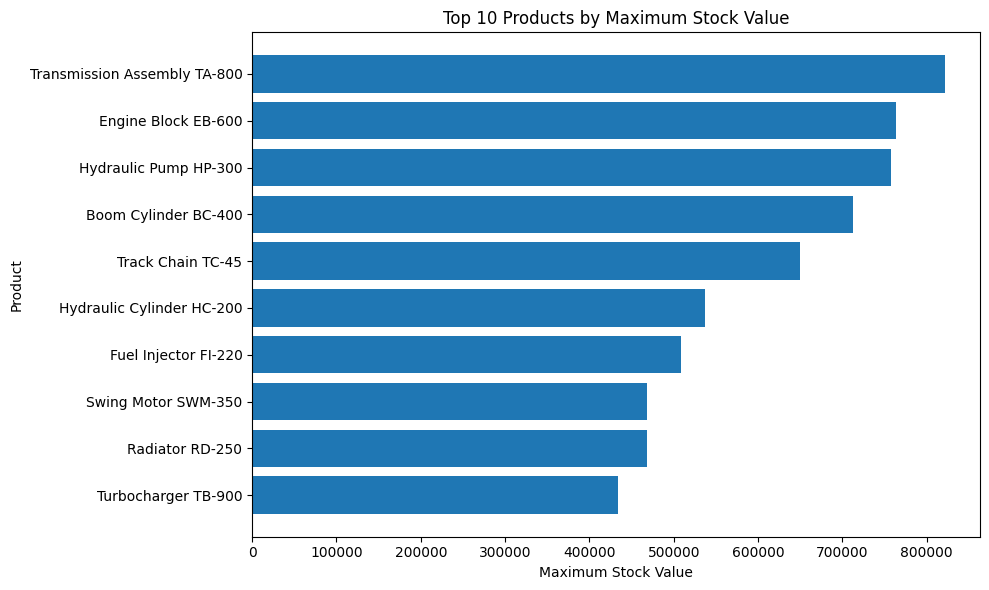

In [41]:
top_max_stock_value = (
    inventory_analysis
    .sort_values(
        "max_stock_value",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_max_stock_value["product_name"].astype(str),
    top_max_stock_value["max_stock_value"]
)

plt.xlabel("Maximum Stock Value")
plt.ylabel("Product")
plt.title("Top 10 Products by Maximum Stock Value")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [45]:
# Add ABC classification to inventory_analysis

inventory_analysis = inventory_analysis.merge(
    abc_analysis[
        [
            "product_id",
            "ABC_class"
        ]
    ],
    on="product_id",
    how="left"
)

display(
    inventory_analysis[
        [
            "product_id",
            "product_name",
            "ABC_class"
        ]
    ].head(20)
)

,product_id,product_name,ABC_class
0,P001,Hydraulic Pump HP-300,A
1,P002,Engine Oil Filter OF-90,C
2,P003,Air Filter AF-120,C
3,P004,Track Chain TC-45,A
4,P005,Fuel Injector FI-220,A
5,P006,Alternator ALT-500,A
6,P007,Hydraulic Hose HH-60,B
7,P008,Bucket Tooth BT-10,C
8,P009,Starter Motor SM-700,A
9,P010,Turbocharger TB-900,A


Final KPIs

In [46]:
# Final KPIs

# Total number of products analysed
total_products_analysed = (
    inventory_analysis["product_id"].nunique()
)

# Stock requirement quantities
total_safety_stock = (
    inventory_analysis["safety_stock"].sum()
)

total_reorder_level = (
    inventory_analysis["reorder_level"].sum()
)

total_max_stock_level = (
    inventory_analysis["max_stock_level"].sum()
)

# Stock requirement values
total_safety_stock_value = (
    inventory_analysis["safety_stock_value"].sum()
)

total_reorder_stock_value = (
    inventory_analysis["reorder_stock_value"].sum()
)

total_max_stock_value = (
    inventory_analysis["max_stock_value"].sum()
)

# Average supplier/product lead time
average_lead_time = (
    inventory_analysis["lead_time_days"].mean()
)

# ABC classification counts
a_class_products = (
    inventory_analysis["ABC_class"]
    .eq("A")
    .sum()
)

b_class_products = (
    inventory_analysis["ABC_class"]
    .eq("B")
    .sum()
)

c_class_products = (
    inventory_analysis["ABC_class"]
    .eq("C")
    .sum()
)

# Product movement counts
fast_moving_products = (
    inventory_analysis["movement_category"]
    .eq("Fast-Moving")
    .sum()
)

medium_moving_products = (
    inventory_analysis["movement_category"]
    .eq("Medium-Moving")
    .sum()
)

slow_moving_products = (
    inventory_analysis["movement_category"]
    .eq("Slow-Moving")
    .sum()
)

KPI Table

In [47]:
week5_kpis = pd.DataFrame({
    "KPI": [
        "Products Analysed",
        "Total Safety Stock",
        "Total Reorder Level",
        "Total Maximum Stock Level",
        "Safety Stock Value",
        "Reorder Stock Value",
        "Maximum Stock Value",
        "Average Lead Time (Days)",
        "A-Class Products",
        "B-Class Products",
        "C-Class Products"
    ],

    "Value": [
        total_products_analysed,
        total_safety_stock,
        total_reorder_level,
        total_max_stock_level,
        total_safety_stock_value,
        total_reorder_stock_value,
        total_max_stock_value,
        average_lead_time,
        a_class_products,
        b_class_products,
        c_class_products
    ]
})

display(week5_kpis)

,KPI,Value
0,Products Analysed,30.0
1,Total Safety Stock,604.0
2,Total Reorder Level,1192.0
3,Total Maximum Stock Level,3145.0
4,Safety Stock Value,1924350.0
5,Reorder Stock Value,3623000.0
6,Maximum Stock Value,9915650.0
7,Average Lead Time (Days),17.0
8,A-Class Products,16.0
9,B-Class Products,8.0


Format the KPI Table

In [48]:
week5_kpis_formatted = week5_kpis.copy()

currency_kpis = [
    "Safety Stock Value",
    "Reorder Stock Value",
    "Maximum Stock Value"
]

decimal_kpis = [
    "Average Lead Time (Days)"
]

for index, row in week5_kpis_formatted.iterrows():

    if row["KPI"] in currency_kpis:
        week5_kpis_formatted.loc[index, "Value"] = (
            f"£{float(row['Value']):,.2f}"
        )

    elif row["KPI"] in decimal_kpis:
        week5_kpis_formatted.loc[index, "Value"] = (
            f"{float(row['Value']):,.2f}"
        )

    else:
        week5_kpis_formatted.loc[index, "Value"] = (
            f"{float(row['Value']):,.2f}"
        )

display(week5_kpis_formatted)

/tmp/ipykernel_1071/2700153894.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  week5_kpis_formatted.loc[index, "Value"] = (


,KPI,Value
0,Products Analysed,30.00
1,Total Safety Stock,604.00
2,Total Reorder Level,"1,192.00"
3,Total Maximum Stock Level,"3,145.00"
4,Safety Stock Value,"£1,924,350.00"
5,Reorder Stock Value,"£3,623,000.00"
6,Maximum Stock Value,"£9,915,650.00"
7,Average Lead Time (Days),17.00
8,A-Class Products,16.00
9,B-Class Products,8.00


Save Results

In [49]:
OUTPUT_PATH = Path("../analysis")

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

In [51]:
inventory_analysis.to_csv(
    OUTPUT_PATH / "inventory_health_summary.csv",
    index=False
)

abc_analysis.to_csv(
    OUTPUT_PATH / "abc_classification.csv",
    index=False
)

week5_kpis.to_csv(
    OUTPUT_PATH / "week5_inventory_kpis.csv",
    index=False
)

product_inventory.to_csv(
    OUTPUT_PATH / "product_stock_requirements.csv",
    index=False
)

Create Visualization Folder

In [52]:
VIS_PATH = Path("../visualisations")

VIS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

Save Stock Requirement Charts

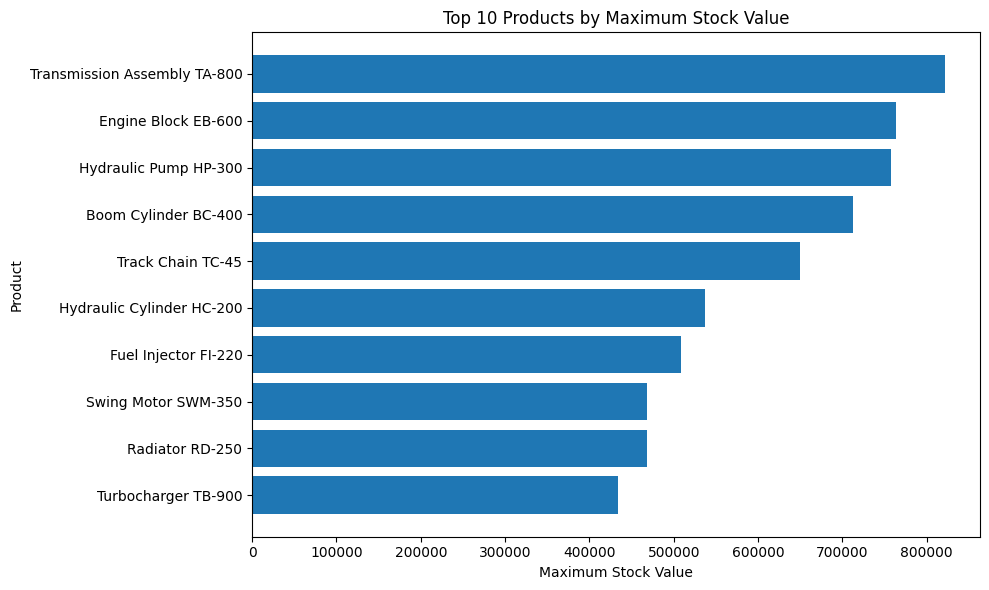

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_max_stock_value["product_name"].astype(str),
    top_max_stock_value["max_stock_value"]
)

plt.xlabel("Maximum Stock Value")
plt.ylabel("Product")
plt.title("Top 10 Products by Maximum Stock Value")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    VIS_PATH / "top_max_stock_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save ABC Chart

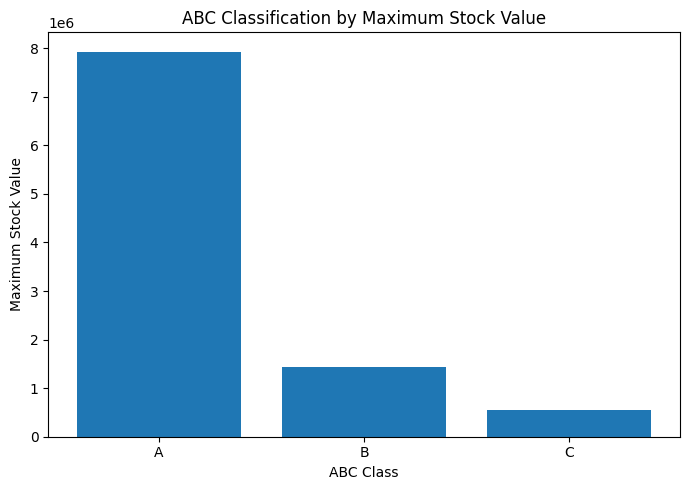

In [54]:
plt.figure(figsize=(7, 5))

plt.bar(
    abc_summary["ABC_class"],
    abc_summary["maximum_stock_value"]
)

plt.xlabel("ABC Class")
plt.ylabel("Maximum Stock Value")
plt.title("ABC Classification by Maximum Stock Value")

plt.tight_layout()

plt.savefig(
    VIS_PATH / "abc_classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save Lead Time Chart

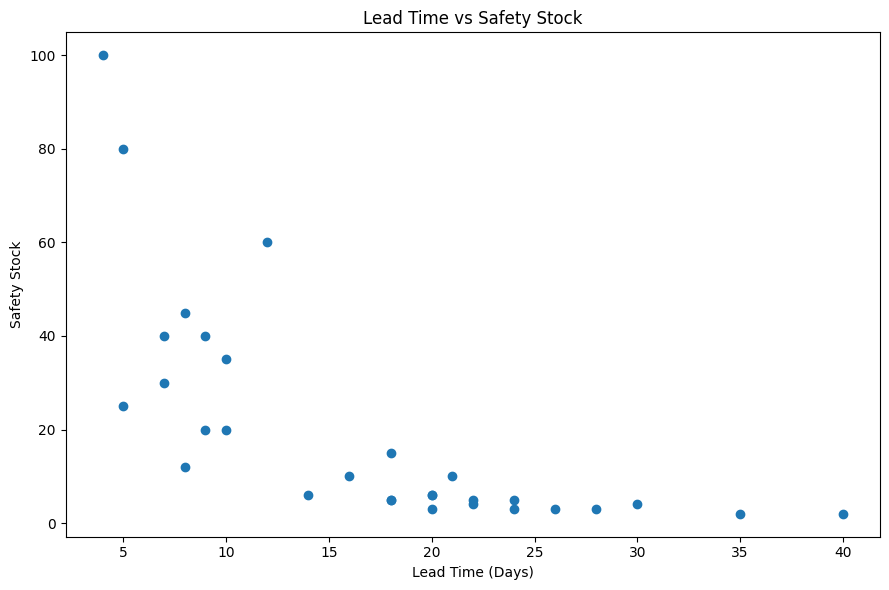

In [55]:
plt.figure(figsize=(9, 6))

plt.scatter(
    product_inventory["lead_time_days"],
    product_inventory["safety_stock"]
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Safety Stock")
plt.title("Lead Time vs Safety Stock")

plt.tight_layout()

plt.savefig(
    VIS_PATH / "lead_time_vs_safety_stock.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()